In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../Telco-Customer-Churn.csv")
print(df.shape)

(7043, 21)


In [14]:
churn_counts=df['Churn'].value_counts()
churn_ratio=churn_counts['No']/churn_counts['Yes']
print(churn_counts)
print(f"\nimbalance ratio: {churn_ratio:.2f}:1(Not churned:Churned)")

Churn
No     5174
Yes    1869
Name: count, dtype: int64

imbalance ratio: 2.77:1(Not churned:Churned)


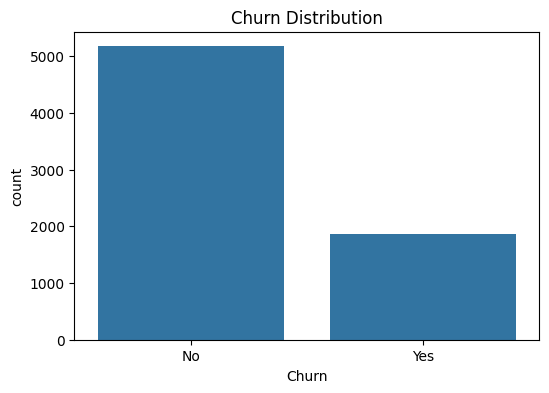

In [19]:

plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df)
plt.title('Churn Distribution')
plt.savefig('../outputs/plots/churn_distribution.png')
plt.show()

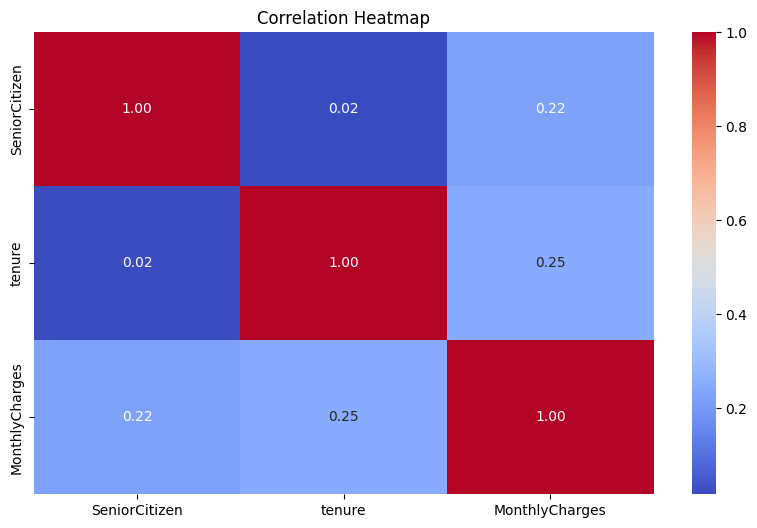

In [20]:
numerical_cols=df.select_dtypes(include='number')
plt.figure(figsize=(10,6))
sns.heatmap(numerical_cols.corr(),annot=True,fmt=".2f",cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.savefig('../outputs/plots/correlation_heatmap.png')
plt.show()

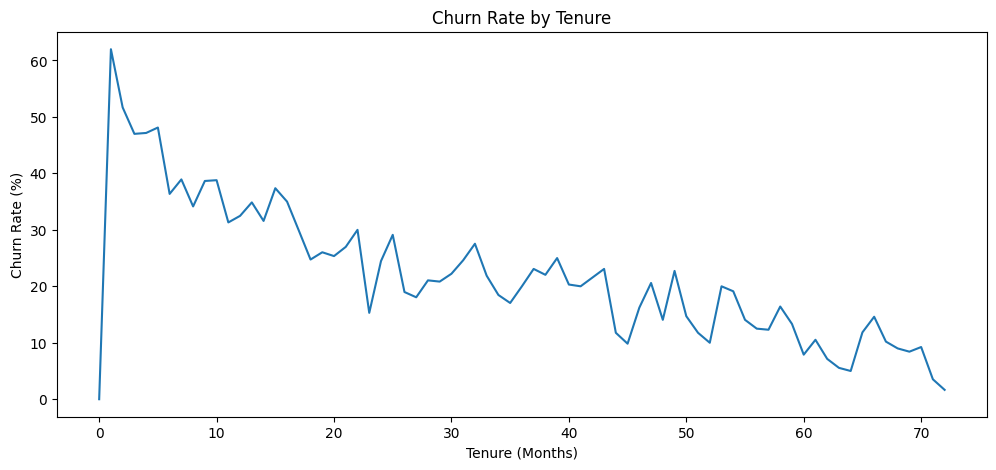

In [21]:
tenure_churn=df.groupby('tenure')['Churn'].apply(lambda x:(x=='Yes').mean()*100).reset_index()
tenure_churn.columns=['tenure','churn_rate']

plt.figure(figsize=(12,5))
plt.plot(tenure_churn['tenure'],tenure_churn['churn_rate'])
plt.title('Churn Rate by Tenure')
plt.xlabel('Tenure (Months)')
plt.ylabel('Churn Rate (%)')
plt.savefig('../outputs/plots/churn_rate_by_tenure.png')
plt.show()

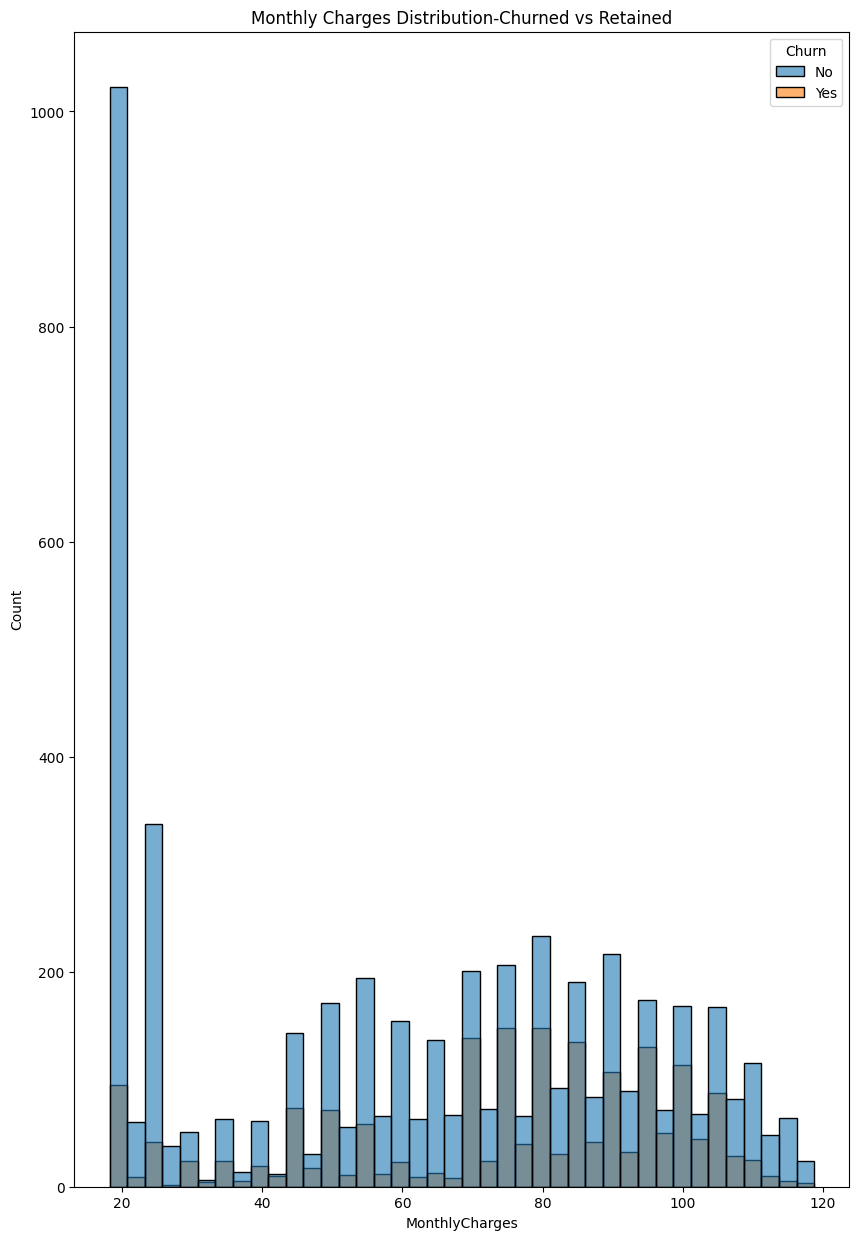

In [24]:
plt.figure(figsize=(10,15))
sns.histplot(data=df,x='MonthlyCharges',hue='Churn',bins=40,alpha=0.6)
plt.title('Monthly Charges Distribution-Churned vs Retained')
plt.savefig('../outputs/plots/monthly_charges_distribution.png')
plt.show()